## Load & Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_excel('US_Superstore_data.xls')

print('Shape:', df.shape)
print('Missing values:\n', df.isnull().sum()[df.isnull().sum() > 0])
print('\nDate range:', df['Order Date'].min().date(), '→', df['Order Date'].max().date())
df.head(3)

Shape: (9994, 21)
Missing values:
 Series([], dtype: int64)

Date range: 2014-01-03 → 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


## Which States Have the Most Sales?

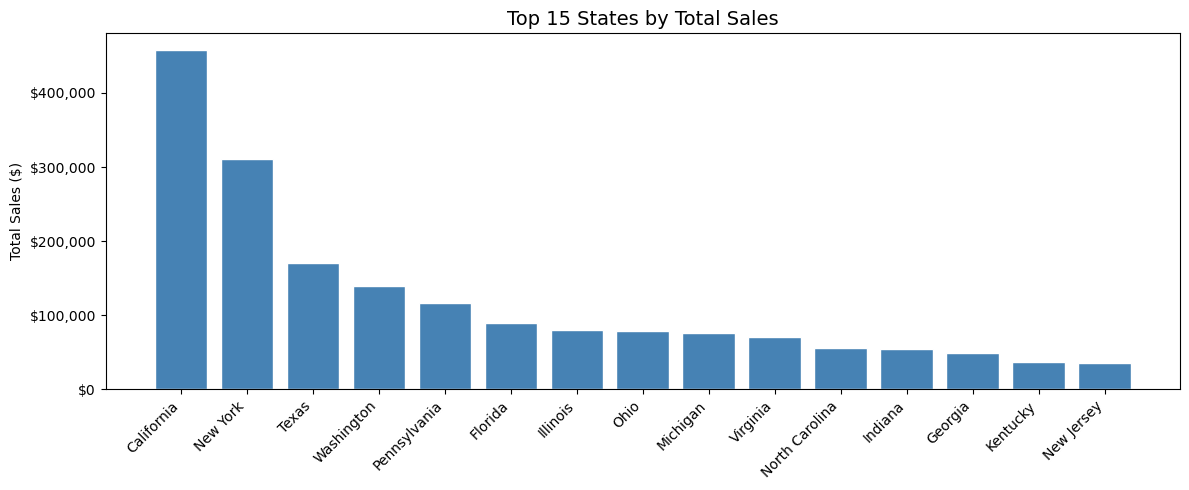

Top 5 states by sales:
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


In [2]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
bars = plt.bar(state_sales.index, state_sales.values, color='steelblue', edgecolor='white')
plt.title('Top 15 States by Total Sales', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

print('Top 5 states by sales:')
print(state_sales.head())

## New York vs California: Sales & Profit

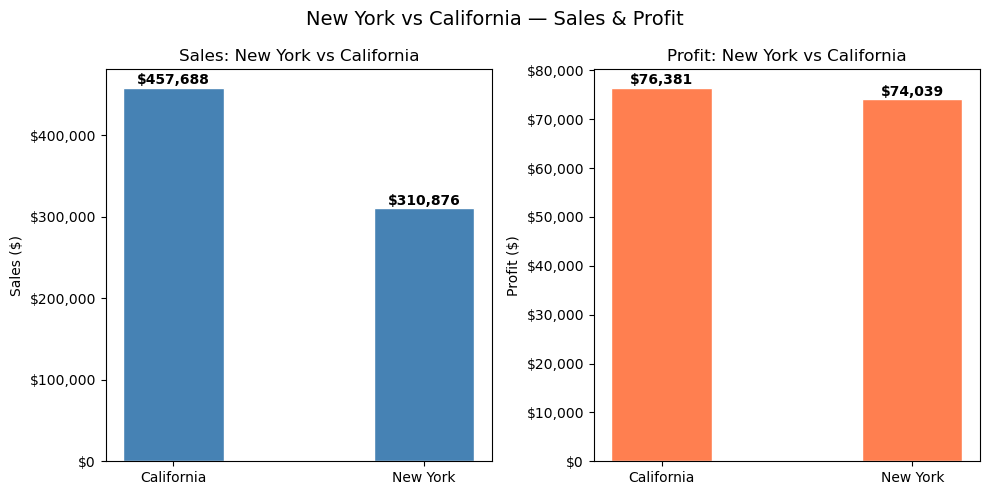

                  Sales      Profit
State                              
California  457687.6315  76381.3871
New York    310876.2710  74038.5486


In [3]:
ny_ca = df[df['State'].isin(['New York', 'California'])]
compare = ny_ca.groupby('State')[['Sales', 'Profit']].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, col, color in zip(axes, ['Sales', 'Profit'], ['steelblue', 'coral']):
    ax.bar(compare.index, compare[col], color=color, edgecolor='white', width=0.4)
    ax.set_title(f'{col}: New York vs California')
    ax.set_ylabel(f'{col} ($)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    for i, v in enumerate(compare[col]):
        ax.text(i, v + abs(v)*0.01, f'${v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('New York vs California — Sales & Profit', fontsize=14)
plt.tight_layout()
plt.show()

print(compare)

## Outstanding Customer in New York

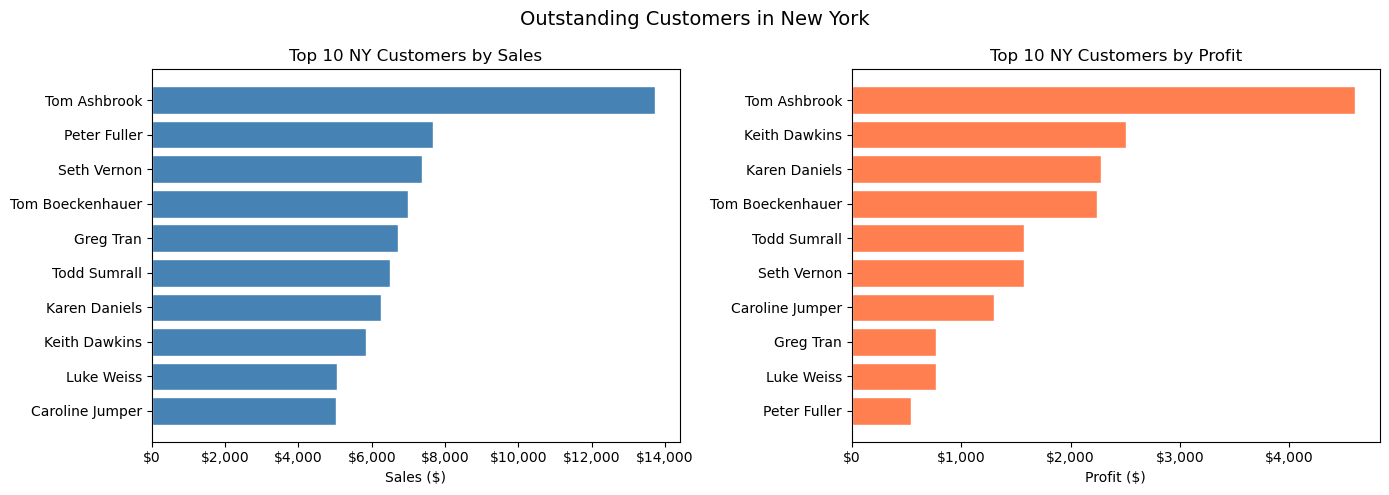

Top customer in NY by Sales: Tom Ashbrook — $13,723


In [4]:
ny = df[df['State'] == 'New York']
top_ny = ny.groupby('Customer Name')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ['Sales', 'Profit'], ['steelblue', 'coral']):
    data = top_ny[col].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color, edgecolor='white')
    ax.set_title(f'Top 10 NY Customers by {col}')
    ax.set_xlabel(f'{col} ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Outstanding Customers in New York', fontsize=14)
plt.tight_layout()
plt.show()

best = top_ny['Sales'].idxmax()
print(f'Top customer in NY by Sales: {best} — ${top_ny.loc[best, "Sales"]:,.0f}')

## State Profitability Comparison

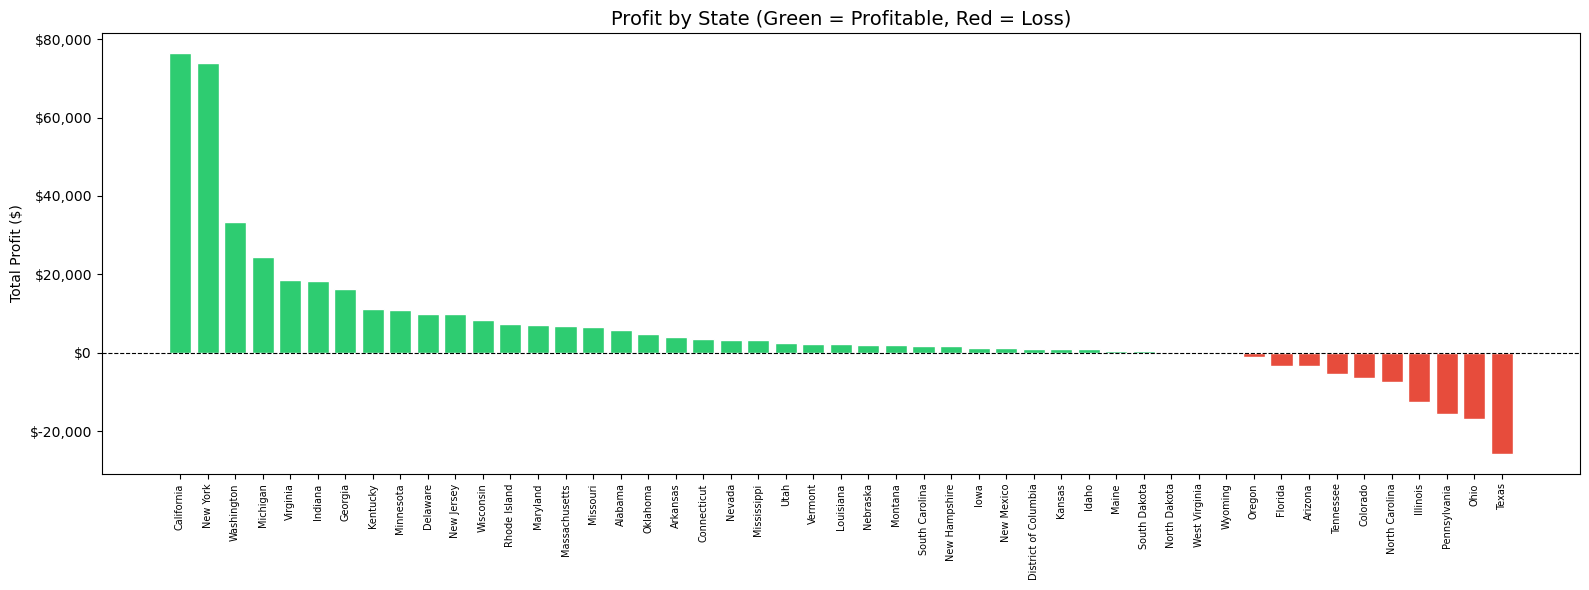

States with negative profit (10):
State
Oregon            -1190.4705
Florida           -3399.3017
Arizona           -3427.9246
Tennessee         -5341.6936
Colorado          -6527.8579
North Carolina    -7490.9122
Illinois         -12607.8870
Pennsylvania     -15559.9603
Ohio             -16971.3766
Texas            -25729.3563


In [5]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in state_profit.values]

plt.figure(figsize=(16, 6))
plt.bar(state_profit.index, state_profit.values, color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Profit by State (Green = Profitable, Red = Loss)', fontsize=14)
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=90, fontsize=7)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

loss_states = state_profit[state_profit < 0]
print(f'States with negative profit ({len(loss_states)}):')
print(loss_states.to_string())

## Pareto Principle: Do 20% of Customers Drive 80% of Profit?

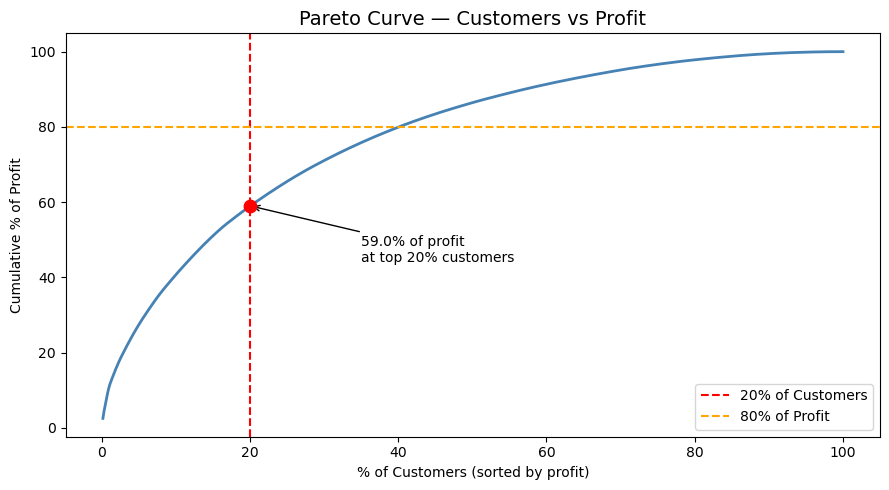

Top 20% of customers contribute 59.0% of total profit.


In [6]:
# Sort customers by profit descending, keep only positive contributors
cust_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)
cust_profit = cust_profit[cust_profit > 0]

cum_profit = cust_profit.cumsum() / cust_profit.sum() * 100
cum_customers = np.arange(1, len(cust_profit) + 1) / len(cust_profit) * 100

# Find where 20% of customers sits
threshold_idx = int(len(cust_profit) * 0.2)
pct_profit_at_20 = cum_profit.iloc[threshold_idx]

plt.figure(figsize=(9, 5))
plt.plot(cum_customers, cum_profit.values, color='steelblue', linewidth=2)
plt.axvline(20, color='red', linestyle='--', label='20% of Customers')
plt.axhline(80, color='orange', linestyle='--', label='80% of Profit')
plt.scatter([20], [pct_profit_at_20], color='red', zorder=5, s=80)
plt.annotate(f'{pct_profit_at_20:.1f}% of profit\nat top 20% customers',
             xy=(20, pct_profit_at_20), xytext=(35, pct_profit_at_20 - 15),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.title('Pareto Curve — Customers vs Profit', fontsize=14)
plt.xlabel('% of Customers (sorted by profit)')
plt.ylabel('Cumulative % of Profit')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Top 20% of customers contribute {pct_profit_at_20:.1f}% of total profit.')

## Top 20 Cities by Sales & Profit

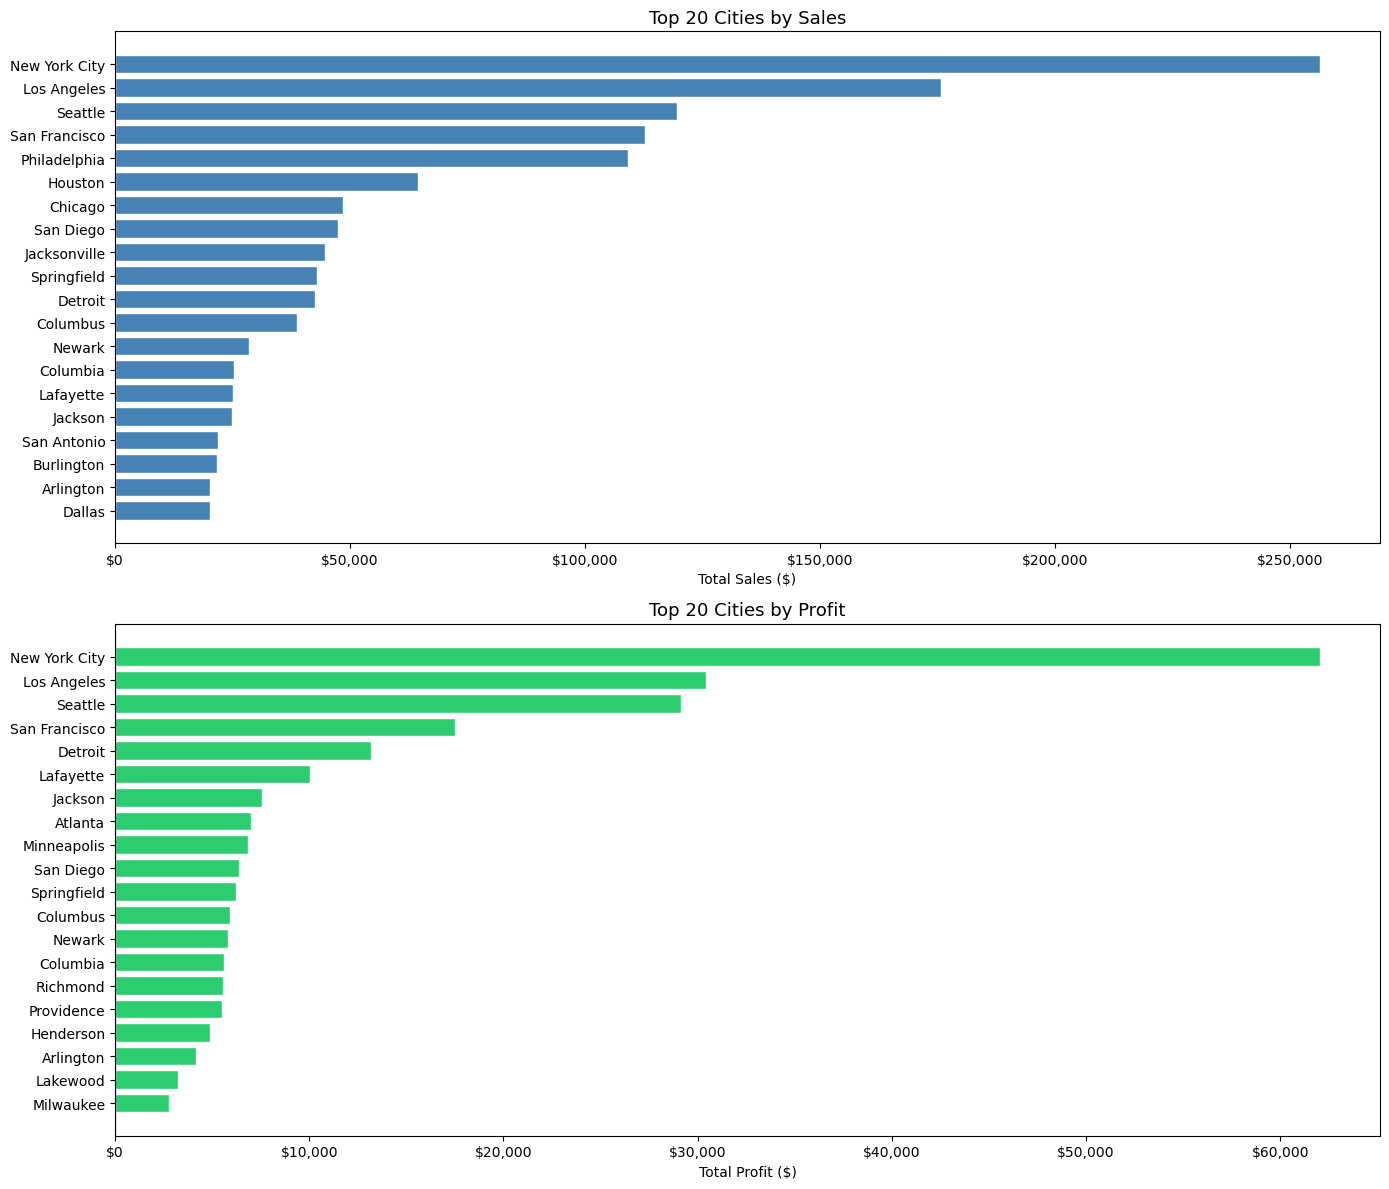

Cities in Top 20 Sales but NOT Top 20 Profit: {'Burlington', 'Philadelphia', 'San Antonio', 'Dallas', 'Chicago', 'Houston', 'Jacksonville'}


In [7]:
city_agg = df.groupby('City')[['Sales', 'Profit']].sum()
top20_sales  = city_agg['Sales'].sort_values(ascending=False).head(20)
top20_profit = city_agg['Profit'].sort_values(ascending=False).head(20)

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Top 20 by Sales
axes[0].barh(top20_sales.index[::-1], top20_sales.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 20 Cities by Sales', fontsize=13)
axes[0].set_xlabel('Total Sales ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Top 20 by Profit — color negative profit red
colors_p = ['#2ecc71' if v > 0 else '#e74c3c' for v in top20_profit.values[::-1]]
axes[1].barh(top20_profit.index[::-1], top20_profit.values[::-1], color=colors_p, edgecolor='white')
axes[1].set_title('Top 20 Cities by Profit', fontsize=13)
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

# Cities that appear in top 20 sales but NOT top 20 profit
diff = set(top20_sales.index) - set(top20_profit.index)
print('Cities in Top 20 Sales but NOT Top 20 Profit:', diff)

## Top 20 Customers by Sales

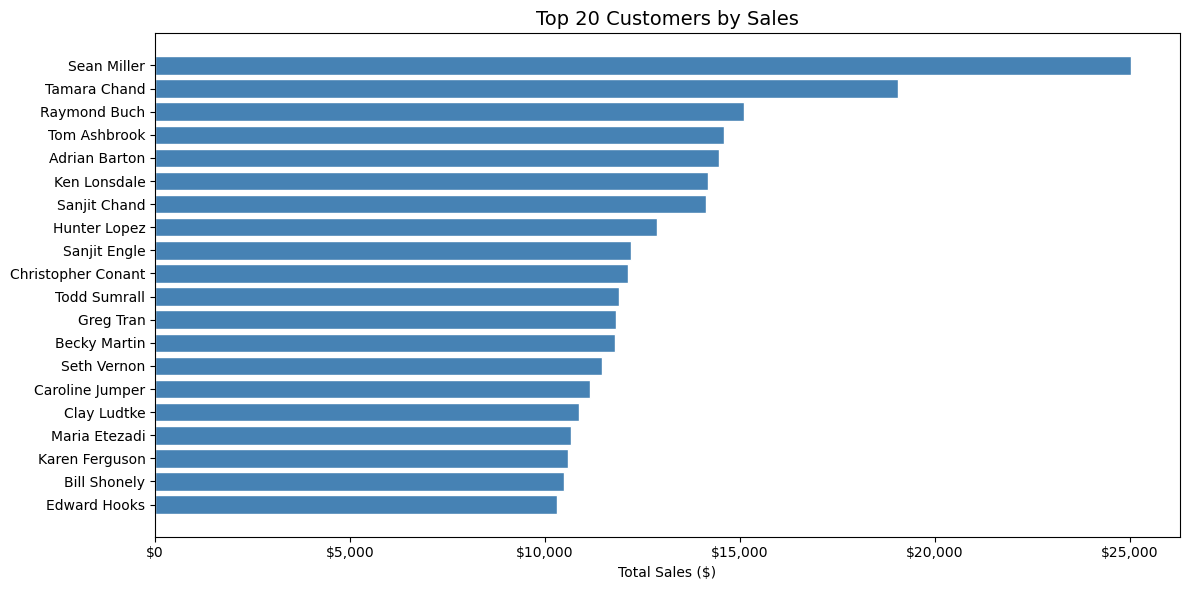

In [8]:
top20_cust = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
plt.barh(top20_cust.index[::-1], top20_cust.values[::-1], color='steelblue', edgecolor='white')
plt.title('Top 20 Customers by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Pareto Curve: Customers vs Sales

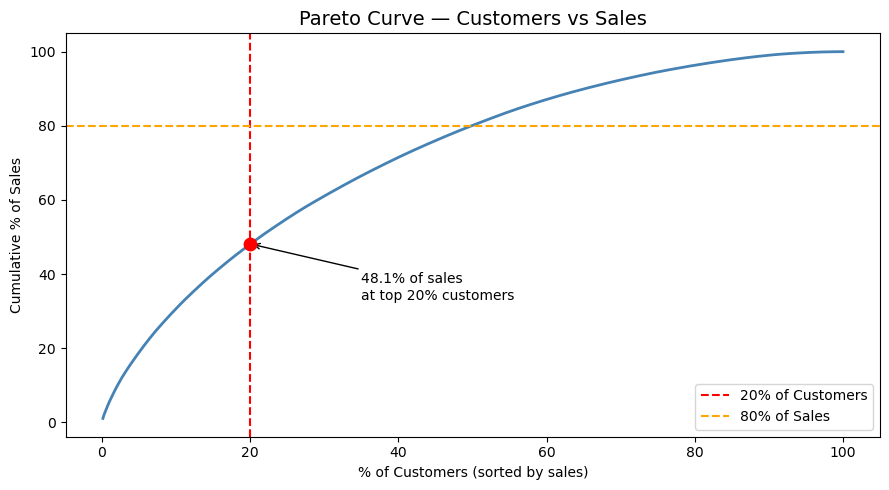

Top 20% of customers generate 48.1% of total sales.


In [9]:
cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

cum_sales     = cust_sales.cumsum() / cust_sales.sum() * 100
cum_cust_pct  = np.arange(1, len(cust_sales) + 1) / len(cust_sales) * 100

threshold_idx = int(len(cust_sales) * 0.2)
pct_sales_at_20 = cum_sales.iloc[threshold_idx]

plt.figure(figsize=(9, 5))
plt.plot(cum_cust_pct, cum_sales.values, color='steelblue', linewidth=2)
plt.axvline(20, color='red', linestyle='--', label='20% of Customers')
plt.axhline(80, color='orange', linestyle='--', label='80% of Sales')
plt.scatter([20], [pct_sales_at_20], color='red', zorder=5, s=80)
plt.annotate(f'{pct_sales_at_20:.1f}% of sales\nat top 20% customers',
             xy=(20, pct_sales_at_20), xytext=(35, pct_sales_at_20 - 15),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.title('Pareto Curve — Customers vs Sales', fontsize=14)
plt.xlabel('% of Customers (sorted by sales)')
plt.ylabel('Cumulative % of Sales')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Top 20% of customers generate {pct_sales_at_20:.1f}% of total sales.')

## Marketing Recommendations

Based on the analysis:

**States to prioritize:**
- **California & New York** are the top sales states — allocate the most marketing budget here.
- **Texas, Pennsylvania, Washington** round out the top 5 — strong secondary targets.
- **States with negative profit** (e.g. Texas, Ohio, Pennsylvania) need discount strategy review before further investment.

**Cities to prioritize:**
- **New York City, Los Angeles, Seattle, San Francisco, Philadelphia** lead in both sales and profit — ideal for premium campaigns.
- Cities in top-20 sales but NOT top-20 profit signal discount abuse — investigate and tighten pricing.

**Customer strategy:**
- The top 20% of customers drive a disproportionate share of both sales and profit (Pareto confirmed).
- Launch a **loyalty/VIP program** targeting these high-value customers to retain them.
- Identify the outstanding New York customer and replicate their engagement pattern.